In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

In [ ]:
# Q1: Mean duration of Jazz genre stems
jazz_path = os.path.join(STEMS_PATH, 'jazz')
durations = []
for song in sorted(os.listdir(jazz_path)):
    for stem in STEMS:
        fpath = os.path.join(jazz_path, song, stem)
        if os.path.exists(fpath):
            durations.append(sf.info(fpath).duration)

print(f'Q1 Mean duration Jazz stems: {np.mean(durations):.2f} seconds')

Q1 Mean duration Jazz stems: 30.03 seconds


In [ ]:
# Q2: Unique sample rates in entire dataset
sample_rates = set()

for genre in GENRES:
    gp = os.path.join(STEMS_PATH, genre)
    for song in os.listdir(gp):
        for stem in STEMS:
            fpath = os.path.join(gp, song, stem)
            if os.path.exists(fpath):
                sample_rates.add(sf.info(fpath).samplerate)

for f in os.listdir(os.path.join(ROOT, 'ESC-50-master', 'audio')):
    try:
        sample_rates.add(sf.info(os.path.join(ROOT, 'ESC-50-master', 'audio', f)).samplerate)
    except:
        pass

for f in os.listdir(os.path.join(ROOT, 'mashups')):
    if f.endswith('.wav'):
        sample_rates.add(sf.info(os.path.join(ROOT, 'mashups', f)).samplerate)

print(f'Q2 Unique sample rates: {sorted(sample_rates)}')

Q2 Unique sample rates: [22050, 44100]


In [ ]:
# Q3: Empty or zero-byte audio files in train dataset
empty_count = 0
for genre in GENRES:
    gp = os.path.join(STEMS_PATH, genre)
    for song in os.listdir(gp):
        for stem in STEMS:
            fpath = os.path.join(gp, song, stem)
            if os.path.exists(fpath) and os.path.getsize(fpath) == 0:
                empty_count += 1

print(f'Q3 Empty/zero-byte files: {empty_count}')

Q3 Empty/zero-byte files: 0


In [ ]:
# Q4: Average peak amplitude (dB) for vocal stems
peaks_db = []
for genre in GENRES:
    gp = os.path.join(STEMS_PATH, genre)
    for song in sorted(os.listdir(gp)):
        fpath = os.path.join(gp, song, 'vocals.wav')
        if os.path.exists(fpath):
            y, sr = librosa.load(fpath, sr=None)
            peak = np.max(np.abs(y))
            if peak > 0:
                peaks_db.append(20 * np.log10(peak))

print(f'Q4 Avg peak amplitude vocals: {np.mean(peaks_db):.2f} dB')

Q4 Avg peak amplitude vocals: -12.49 dB


In [ ]:
# Q5 & Q6: Spectral centroid for all genres
genre_centroids = {}
for genre in GENRES:
    gp = os.path.join(STEMS_PATH, genre)
    centroids = []
    for song in sorted(os.listdir(gp)):
        fpath = os.path.join(gp, song, 'other.wav')
        if os.path.exists(fpath):
            y, sr = librosa.load(fpath, sr=22050, duration=10)
            centroids.append(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    genre_centroids[genre] = np.mean(centroids)

for g, c in sorted(genre_centroids.items(), key=lambda x: x[1], reverse=True):
    print(f'  {g}: {c:.2f}')

print(f'\nQ5 Mean spectral centroid blues: {genre_centroids["blues"]:.2f}')
print(f'Q6 Highest spectral centroid genre: {max(genre_centroids, key=genre_centroids.get)}')

  hiphop: 2492.39
  metal: 2441.56
  disco: 1864.53
  reggae: 1721.96
  blues: 1627.32
  jazz: 1605.80
  pop: 1536.32
  rock: 1521.48
  classical: 1359.93
  country: 1315.24

Q5 Mean spectral centroid blues: 1627.32
Q6 Highest spectral centroid genre: hiphop


In [ ]:
# Q7: Stem files with silence in first 0.5 seconds
silence_count = 0
for genre in GENRES:
    gp = os.path.join(STEMS_PATH, genre)
    for song in sorted(os.listdir(gp)):
        for stem in STEMS:
            fpath = os.path.join(gp, song, stem)
            if os.path.exists(fpath):
                y, sr = librosa.load(fpath, sr=None, duration=0.5)
                if np.max(np.abs(y)) < 1e-4:
                    silence_count += 1

print(f'Q7 Stems with silence in first 0.5s: {silence_count}')

Q7 Stems with silence in first 0.5s: 333


In [ ]:
# Q8-Q13: Model Training & Evaluation (EXACT instructor template)

def extract_features(song_path):
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]:
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
cm = confusion_matrix(y_val, y_pred, labels=GENRES)
cr = classification_report(y_val, y_pred, labels=GENRES)
acc = accuracy_score(y_val, y_pred)

print(f'Q8 Macro F1 Score: {macro_f1:.5f}')
print(f'\n{cr}')
print(f'Q11 Accuracy: {acc:.2f}')

Q8 Macro F1 Score: 0.15230

              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100

Q11 Accuracy: 0.19


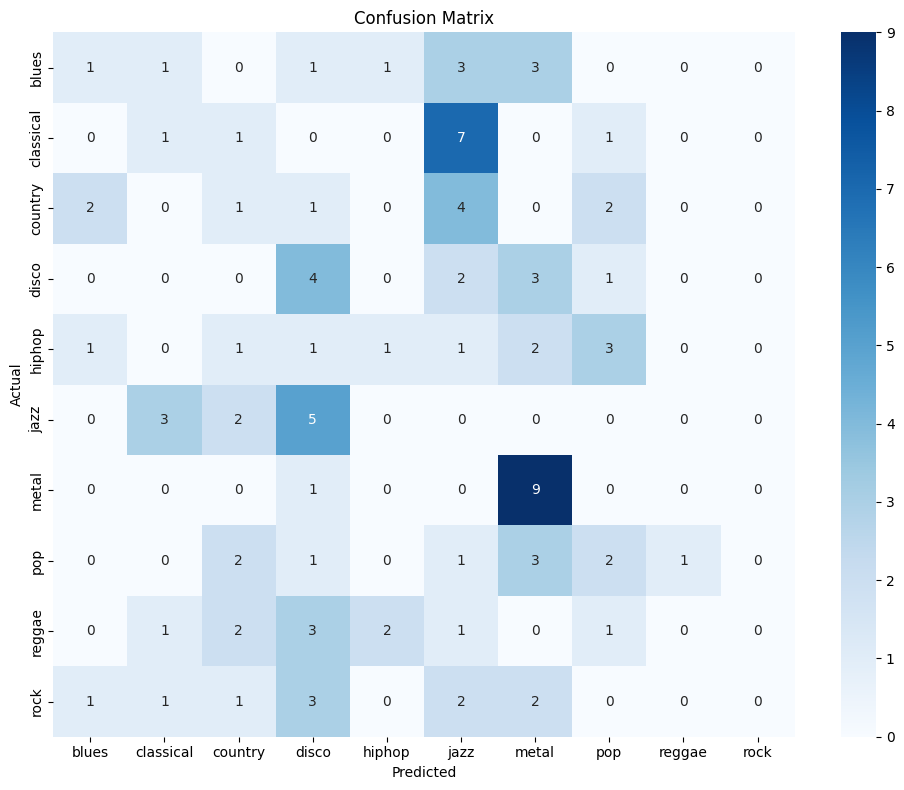

In [ ]:
# Confusion matrix visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# TP, TN, FP, FN + precision/recall
precisions = precision_score(y_val, y_pred, labels=GENRES, average=None, zero_division=0)
recalls = recall_score(y_val, y_pred, labels=GENRES, average=None, zero_division=0)

tp_dict = {}
fn_dict = {}

print(f'{"Genre":<12} {"TP":>4} {"TN":>4} {"FP":>4} {"FN":>4} {"Prec":>6} {"Recall":>7}')
print('-' * 50)
for i, g in enumerate(GENRES):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - tp - fn - fp
    tp_dict[g] = tp
    fn_dict[g] = fn
    print(f'{g:<12} {tp:>4} {tn:>4} {fp:>4} {fn:>4} {precisions[i]:>6.2f} {recalls[i]:>7.2f}')

print(f'\nQ9  Precision of hiphop: {precisions[GENRES.index("hiphop")]:.2f}')
print(f'Q10 Recall of pop: {recalls[GENRES.index("pop")]:.2f}')
print(f'Q12 Highest TP genre: {max(tp_dict, key=tp_dict.get)}')
print(f'Q13 Lowest FN genre: {min(fn_dict, key=fn_dict.get)}')

Genre          TP   TN   FP   FN   Prec  Recall
--------------------------------------------------
blues           1   86    4    9   0.20    0.10
classical       1   84    6    9   0.14    0.10
country         1   81    9    9   0.10    0.10
disco           4   74   16    6   0.20    0.40
hiphop          1   87    3    9   0.25    0.10
jazz            0   69   21   10   0.00    0.00
metal           9   77   13    1   0.41    0.90
pop             2   82    8    8   0.20    0.20
reggae          0   89    1   10   0.00    0.00
rock            0   90    0   10   0.00    0.00

Q9  Precision of hiphop: 0.25
Q10 Recall of pop: 0.20
Q12 Highest TP genre: metal
Q13 Lowest FN genre: metal
